# Question 2: Outreach Prioritization

## Assignment
> Using the selection criteria you made, we have manually picked about 100 sellers at random to check if they were indeed businesses, and for the ones we were unsure of, we gave them a call. It turns out that 83% were business sellers, good job!
>
> It is now March 2025, and the product development for the SMB bundles has completed. We are ready to launch them. The bundles come in two flavors:
>
> - Basic: You will both get you a “Verified seller” icon, a professional seller page, extra pictures for more visibility.
> - Plus: You will get all advantages of Basic, plus extra visibility stickers, and on every ad you get a photo gallery with a link to your other ads.
>
> We have attached a 5% sample of identified prospects. The data consists of monthly usage statistics per category per seller, showing the ads and the features they have used, of the period 2023-2024. In total there are approximately 80k of these prospects in Marktplaats. In our first batch we want to reach out to the 20k sellers that we believe have most potential at this point in time.
>
> To make sure we prioritize the right sellers, we ask you to analyze the data set. We want to call the highest potentials. Provide explorative analyses, and give a recommendation on what type of users to call, and clearly answering why. Any differentiation between which sellers we offer which bundle?
>
> P.S. For this case we only included the SYI sellers, not the Pro sellers, and we excluded cars and jobs ads.


## 0. Exploratory Data Analysis

### 0.1 Dataset Structure

- **Sample:** 129,501 rows, 3,840 sellers, 24 months, 32 categories.
- **Grain:** one row = seller + month + category.
- **Usage fields:** ad insertions and paid feature counts show behavior.
- **Fee fields:** `FEE_...` columns show actual spend and should drive revenue conclusions.
- **Next step:** aggregate to seller level to rank outreach potential.



In [1]:
import importlib
import sys
from pathlib import Path

MODULE_DIR = Path("modules").resolve()
if not MODULE_DIR.exists():
    MODULE_DIR = Path("assignments/smb_bundles/modules").resolve()
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))
import functions as fn

fn = importlib.reload(fn)
fn.set_plot_style()

### 0.2 Basic Checks

Before scoring sellers, check that the sample is clean at the expected seller-month-category grain.



In [2]:
raw_df = fn.read_q2_data()
df = fn.add_q2_row_metrics(raw_df)
seller_summary = fn.q2_seller_level_summary(df)
monthly_summary = fn.q2_monthly_summary(df)
category_summary = fn.q2_top_categories(df, top_n=df[fn.Q2_CATEGORY_COLUMN].nunique())

fn.q2_overview(raw_df)


{'rows': 129501,
 'columns': 18,
 'unique_sellers': 3840,
 'unique_months': 24,
 'first_month': Timestamp('2023-01-01 00:00:00'),
 'last_month': Timestamp('2024-12-01 00:00:00'),
 'unique_categories': 32}

In [3]:
print(fn.q2_data_quality_message(raw_df))


Data quality check: no missing values, no duplicate seller-month-category rows, and no negative metric values.


In [4]:
fn.q2_metric_summary(raw_df)


,Column,Metric,Total,Non-zero Rows,Non-zero Row %
0,N_FREE_AD_INSERTIONS,Free Ad Insertions,"1,051,612",88923,68.7
1,N_AD_RENEWALS,Ad Renewals,"791,611",65896,50.9
2,FEE_PAID_URL,Paid URL,"€380,885",1706,1.3
3,FEE_AD_RENEWALS,Ad Renewals,"€374,518",17912,13.8
4,N_PAID_AD_INSERTIONS,Paid Ad Insertions,"368,786",8633,6.7
5,FEE_PAID_AD_INSERTIONS,Paid Ad Insertions,"€198,692",8633,6.7
6,FEE_DAGTOPPERS,Dagtoppers,"€167,624",10566,8.2
7,FEE_HOMEPAGE,Homepage,"€87,613",1214,0.9
8,N_PAID_URL,Paid URL,"86,868",5087,3.9
9,N_AD_UPCALLS,Ad Upcalls,"71,537",12977,10.0


In [5]:
fn.q2_row_metric_summary(df)


,Total Ad Insertions,Commercial Uses,Total Fees
count,129501.00,129501.00,"129,501"
mean,10.97,10.69,€9.88
std,283.75,453.98,"€1,041.24"
min,0.00,0.00,€0.00
25%,0.00,0.00,€0.00
50%,1.00,1.00,€0.00
75%,3.00,3.00,€1.07
max,60622.00,121172.00,"€373,856.85"


In [6]:
fn.q2_seller_summary_describe(seller_summary)


,Categories,Total Ad Insertions,Free Ad Insertions,Paid Ad Insertions,Total Feature Uses,Paid Marketplace Actions,Paid Visibility Uses,Total Fees,Active Months,Average Ads per Active Month,Average Fees per Active Month
count,3840.00,3840.00,3840.00,3840.00,3840.00,3840.00,3840.00,"3,840",3840.00,3840.00,"3,840"
mean,6.39,369.90,273.86,96.04,264.58,360.62,58.43,€333.30,12.75,18.63,€17.74
std,5.57,5063.77,1520.17,4831.48,3083.84,7771.67,1176.91,"€6,782.24",8.45,232.53,€310.11
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,€0.00,1.00,0.00,€0.00
25%,2.00,6.00,4.00,0.00,3.00,4.00,1.00,€2.71,5.00,1.22,€0.34
50%,5.00,26.00,21.00,1.00,18.00,22.00,4.00,€24.04,12.00,2.60,€2.59
75%,9.00,108.00,92.00,4.00,82.00,93.00,15.00,€108.18,22.00,7.18,€8.84
90%,15.00,441.20,409.00,15.00,341.10,387.10,61.00,€346.49,24.00,22.64,€23.99
95%,18.00,1012.35,962.20,34.00,800.05,840.15,137.05,€751.56,24.00,47.96,€44.12
99%,23.00,4936.32,4744.03,193.61,3645.20,3892.76,658.21,"€3,579.78",24.00,234.16,€149.16


## 1. Framing

- Sample: 3,840 sellers, of which 3,187 (83%) are likely to be SMBs.
- Outreach target: prioritize 25% of the sample, or 960 sellers.
- Basic vs none: helps sellers look more professional and trustworthy.
- Plus vs Basic: helps sellers get more attention and cross-promote between their ads.
- Obvious starting point: rank sellers by total fees; though it has limitations.
- Approach: first review activity, fees, and anomalies; then build a broader outreach readiness score.

## 2. Data Snapshot

- Data quality is strong: no missing values, duplicate seller-month-category rows, or negative metrics.
- Seller activity is highly skewed: most sellers are small, while a small group drives much of the volume and fees.
- Free ad insertions dominate activity; paid usage is concentrated in ad renewals and paid insertions.
- November 2023 has a visible spike, partly driven by seller `65950787`.
- Paid URL, ad renewals, and `Auto-onderdelen` are the main fee concentration points.

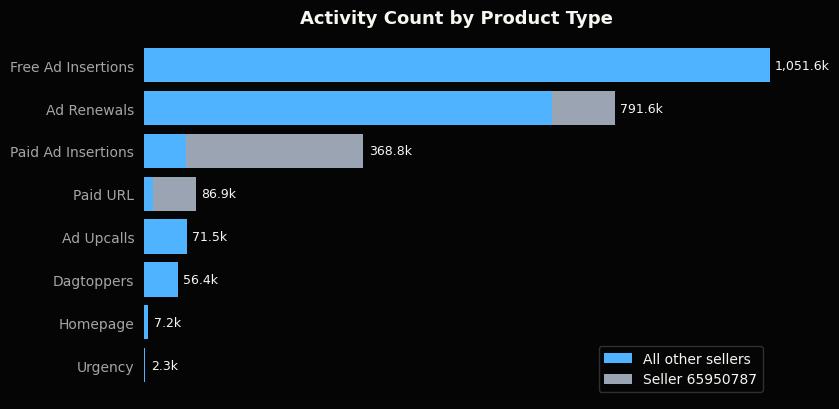

In [7]:
fig, ax = fn.plot_q2_activity_mix_stacked_anomaly(df)

In [8]:
spike_comparison, monthly_without_anomaly_seller = fn.q2_spike_comparison(df, monthly_summary)


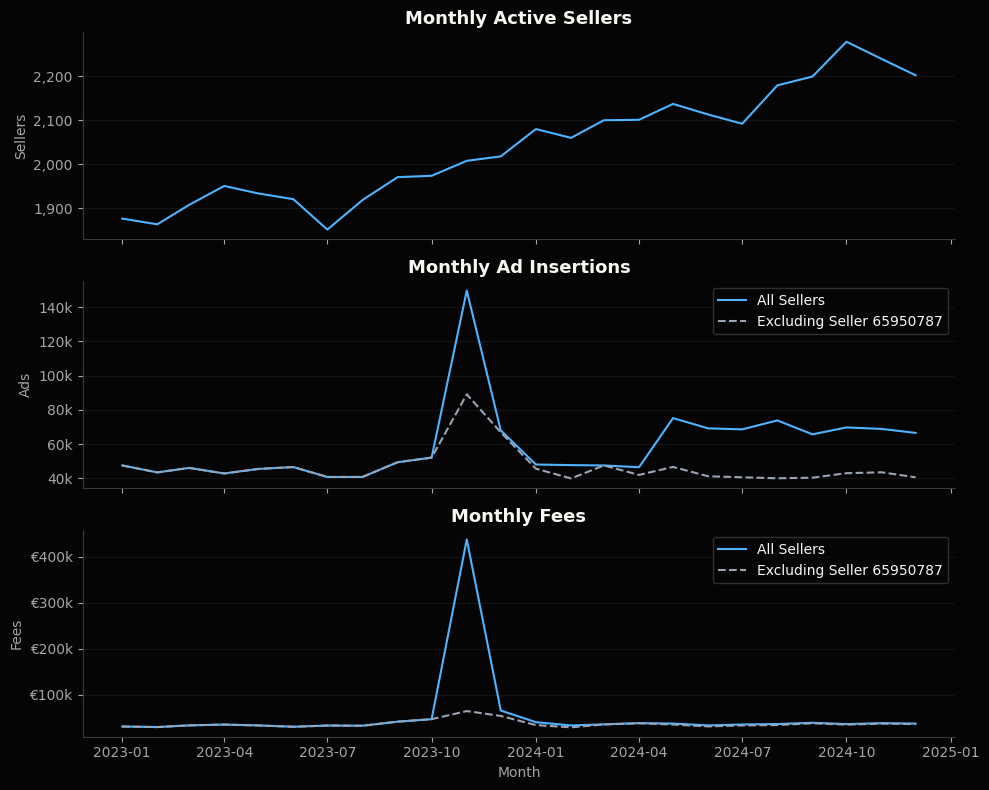

In [9]:
fig, axes = fn.plot_q2_combined_anomaly_overview(monthly_summary, monthly_without_anomaly_seller)


**Spike note:**

- Seller `65950787` in `Auto-onderdelen` explains the extreme November fee spike.
- Even excluding that seller, November remains elevated in ads and fees.
- The remaining lift is broader across sellers/categories, not another single obvious anomaly.


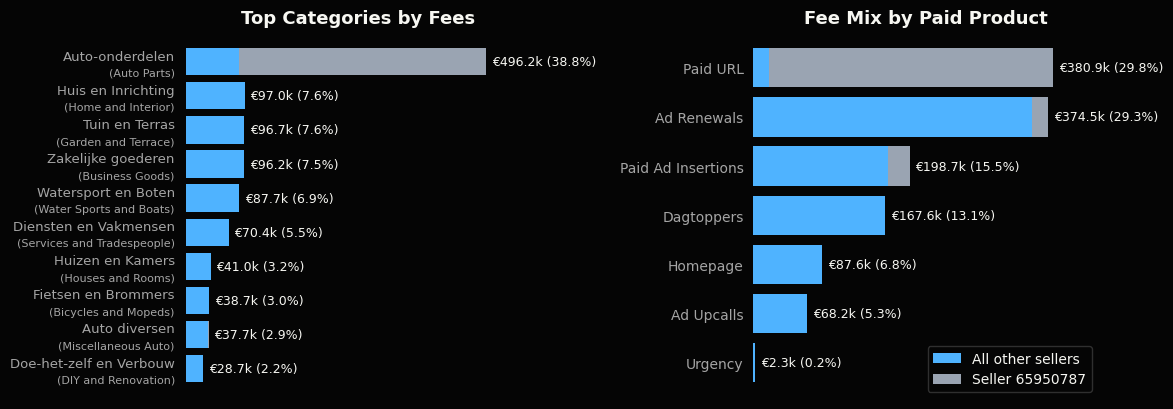

In [10]:
fig, axes = fn.plot_q2_fee_breakdown_stacked_anomaly(category_summary, df)


In [11]:
fn.q2_anomaly_detail(df, monthly_summary)


,Seller ID,Month,Category,Paid Ad Insertions,Paid URL Features,Paid URL Fees,Total Fees,Share of Monthly Ads,Share of Monthly Fees
0,65950787,2023-11,Auto-onderdelen (Auto Parts),"60,622","60,550","€361,604","€373,857",40.5%,85.4%


## 3. Outreach Prioritization

### 3.1 Ranking by Total Fees

Ranking sellers by total fees is the obvious first approach: it targets sellers with the strongest historical willingness to pay.

However, fee-only ranking is narrow. It can miss sellers who are active now, consistent, growing, broad-category, or already familiar with several paid products. Those signals matter for outreach because the first batch should prioritize sellers who are both commercially valuable and likely to see value in a bundle.


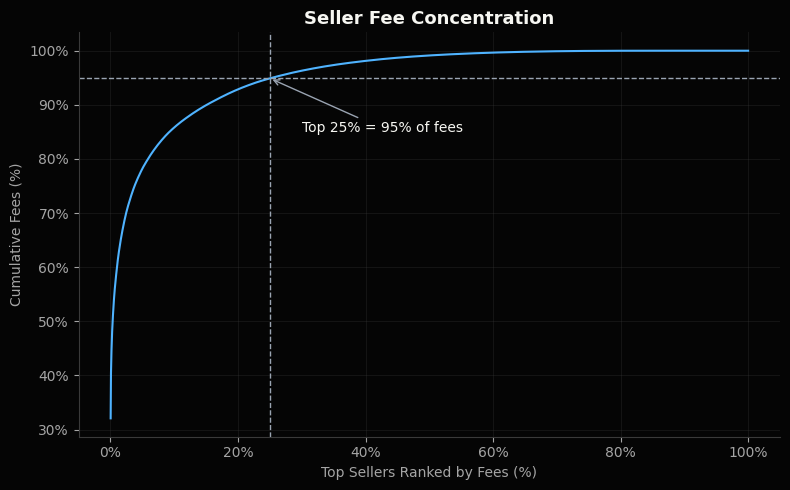

In [12]:
fig, ax = fn.plot_q2_fee_concentration(seller_summary)


### 3.2 Outreach Readiness

- **Goal:** rank outreach readiness, not just historical spend.
- **Why:** fee-only ranking captures high historical spend, but outreach should also capture sellers who are active, growing, consistent, and likely to value the bundle now.
- **Spike callback:** the November spike shows why raw spend alone is too brittle; percentile-based signals keep extreme sellers from dominating the outreach list.
- **Approach:** convert each signal to a seller percentile rank, then take a **simple average** of the six scores into an **outreach readiness score**.
- **Group:** sellers in the top 25% of outreach readiness score are the **outreach ready group**.

| Signal | Purpose | Definition |
|---|---|---|
| Recent paid usage | Current paid-product need / activity | Paid marketplace actions in the last 6 months |
| Consistency | Reliability as a subscription candidate | Number of months with seller activity across 2023-2024 |
| Category breadth | Fit for professional seller page / bundle value | Number of categories used across 2023-2024 |
| Recent growth | Momentum | Recent paid usage vs prior 6 months, with +1 smoothing |
| Total fees | Historical willingness to pay | Total fees paid across 2023-2024 |
| Paid product breadth | Familiarity with multiple paid products | Number of distinct paid marketplace product types used across 2023-2024 |

Each signal is on a 0-100 percentile scale. Very large raw values improve rank but do not dominate the total score.


The table compares the **outreach ready group** with sellers selected by total fees only. Fee values are averages per selected seller; signal values are average percentile scores for each selected cohort.


In [13]:
scored_sellers = fn.q2_score_outreach_readiness(df, seller_summary)
fn.q2_method_comparison_display(scored_sellers)


,Method,Selected Sellers,Avg fees per seller,Avg total fees score,Avg recent paid usage score,Avg consistency score,Avg category breadth score,Avg recent growth score,Avg paid product breadth score,Avg outreach readiness score
0,Outreach ready group,960,"€1,126",76.6,82.5,77.4,71.8,59.7,77.4,74.2
1,Total-fee group,960,"€1,265",87.5,71.4,73.9,52.0,45.3,74.1,67.4


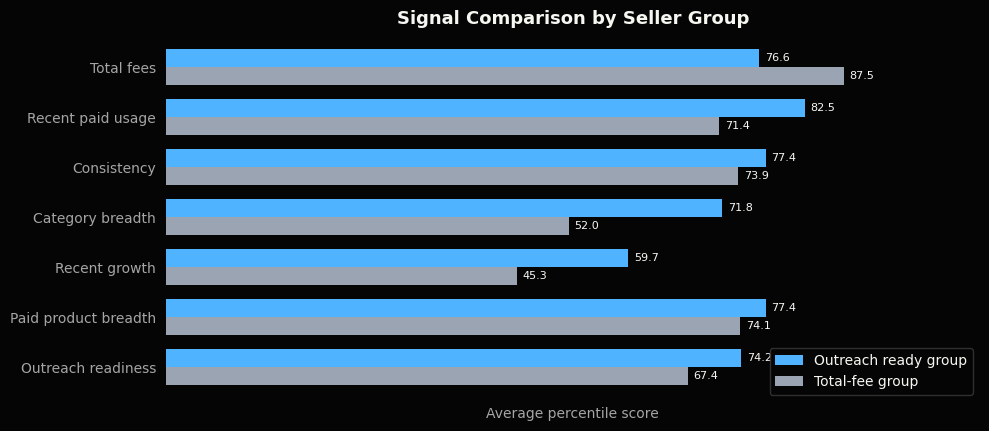

In [14]:
fig, ax = fn.plot_q2_method_score_profile(scored_sellers)


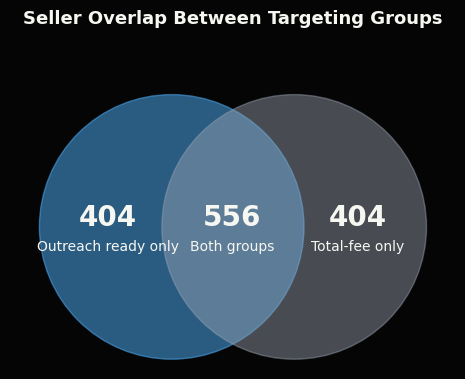

In [15]:
fig, ax = fn.plot_q2_method_overlap_venn(scored_sellers)


In [16]:
fn.q2_selection_summary_display(scored_sellers)


,Selection Group,Sellers,Avg Fees per Seller,Avg 6mo Fees per Seller,Avg Active Months,Avg Recent Paid Usage,Avg Categories,Avg Paid Product Breadth,Median 6mo Paid Action Growth Rate
0,Neither,2476,€18,€6,8.8,9.2,5.1,2.2,+0%
1,Both groups,556,"€1,907",€310,21.6,505.8,9.1,4.9,+12%
2,Outreach ready group only,404,€51,€22,20.0,208.8,13.4,4.2,+87%
3,Total-fee group only,404,€382,€61,17.3,19.2,3.5,3.8,-17%


### 3.3 Bundle Choice

After selecting the **outreach ready group**, use a separate **bundle fit score** to suggest which bundle to pitch.

- **Score:** simple average of three percentile-ranked signals: paid visibility usage, paid product breadth, and listing volume.
- **Why:** Plus helps sellers get more attention and cross-promote between ads, so it fits sellers already using visibility tools or managing more listings.
- **Group:** sellers in the top 40% of bundle fit score inside the outreach ready group are **targeted for Plus**.
- **Targeted for Basic group:** sellers in the outreach ready group who are not targeted for Plus are **targeted for Basic**.

| Signal | Raw usage / definition | Score calculation | Why it fits Plus |
|---|---|---|---|
| Paid visibility usage | Count of Dagtoppers, Homepage, Paid URL, Ad Upcalls, and Urgency actions across 2023-2024 | Seller percentile rank | Direct match to Plus visibility value |
| Paid product breadth | Number of distinct paid product types used across 2023-2024 | Seller percentile rank | Shows familiarity with multiple paid tools |
| Listing volume | Total free and paid ad insertions across 2023-2024 | Seller percentile rank | More listings create more cross-ad promotion value |

Signals not used in bundle fit:

| Signal | Reason |
|---|---|
| Category breadth | Listing volume is a clearer fit for cross-ad promotion. |
| Recent paid usage | Useful for outreach readiness, but too broad for Basic vs Plus choice. |
| Consistency | Good subscription-fit signal, but does not distinguish Basic vs Plus. |
| Recent growth | Shows momentum, but not which bundle fits better. |
| Total fees | Shows willingness to pay, but would make Plus selection too spend-driven. |

- **Suggested split:** target Plus for the highest bundle-fit sellers in the outreach ready group. In this first pass, use the top 40% as a practical starting point; recalibrate after outreach using response and conversion data.
- **Alternative:** use no fixed 40%; show sellers ranked by bundle fit score and let Sales choose based on capacity.
- **Future improvement:** calibrate this split with response, conversion, and upgrade data after outreach starts.

The table below compares sellers **targeted for Plus** with sellers **targeted for Basic** inside the outreach ready group. Fee values are averages per selected seller; signal values are average percentile scores.


In [17]:
fn.q2_bundle_targeting_display(scored_sellers)


,Target Group,Selected Sellers,Avg fees per seller,Avg paid visibility score,Avg paid product breadth score,Avg listing volume score,Avg bundle fit score,Avg outreach readiness score
0,Targeted for Plus group,384,"€2,230",89.6,87.6,85.6,87.6,77.5
1,Targeted for Basic group,576,€389,68.9,70.7,69.1,69.6,72.0


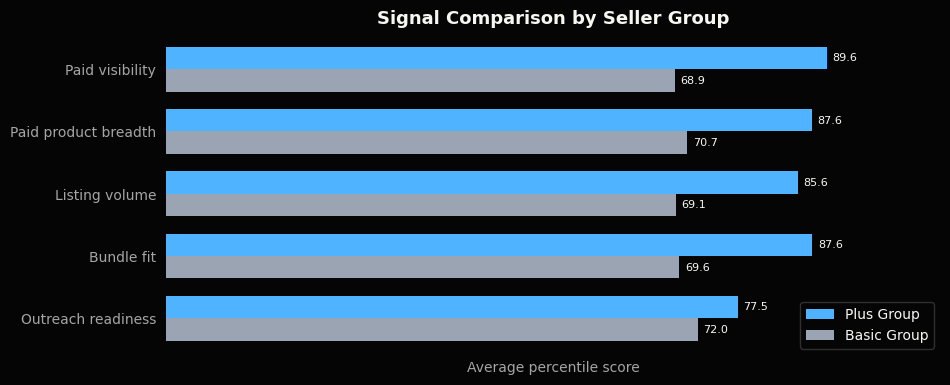

In [18]:
fig, ax = fn.plot_q2_bundle_score_profile(scored_sellers)


### 3.4 Recommendation

Use the **outreach ready group** for the first outreach batch.

- It keeps commercial value in the model, but avoids over-indexing on historical spend.
- It adds sellers who are active, consistent, multi-category, growing, and already familiar with paid products.
- These traits are closer to likely outreach response than fee history alone.


### 3.5 Next Step: Outcome-Based Ranking

- After initial outreach, supervised learning could replace the manual score.
- Train on response, conversion, and post-signup value.
- Keep the ranking explainable for Sales and leadership.



## 4. Seller Outreach Readiness Output

The exported CSV is a compact seller-level prioritization file.

- `_score` columns are final decision scores.
- `_percentile` columns are individual signal percentile ranks.
- Boolean flags identify sellers in the outreach-ready group and sellers targeted for Plus.
- Raw signal values are excluded to keep the deliverable focused on prioritization.

In [19]:
q2_scored_sellers = fn.q2_scored_sellers_export(scored_sellers)
fn.Q2_SCORED_SELLERS_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
q2_scored_sellers.to_csv(fn.Q2_SCORED_SELLERS_CSV_PATH, index=False)

q2_scored_sellers.head(10)


,seller_id,outreach_readiness_score,bundle_fit_score,recent_paid_usage_percentile,consistency_percentile,category_breadth_percentile,recent_growth_percentile,total_fees_percentile,paid_visibility_percentile,paid_product_breadth_percentile,listing_volume_percentile,is_outreach_ready_group,is_targeted_for_plus_group
0,48514286,93.76,94.71,98.62,90.21,99.00,88.78,90.57,96.17,95.39,92.58,True,True
1,24910526,90.31,91.51,93.26,90.21,97.06,98.05,67.93,79.31,95.39,99.82,True,True
2,37013128,90.14,93.93,95.51,90.21,93.40,78.20,97.14,98.85,86.38,96.56,True,True
3,71460313,89.00,97.44,99.40,90.21,80.82,64.61,99.90,99.90,99.09,93.33,True,True
4,88804021,88.91,87.37,93.26,65.44,87.99,94.21,97.19,83.76,95.39,82.94,True,True
5,12594959,88.88,94.96,98.20,90.21,91.81,58.98,98.70,95.59,95.39,93.91,True,True
6,70029667,88.68,89.93,98.07,90.21,97.88,60.78,98.75,90.31,86.38,93.09,True,True
7,44641783,87.98,89.11,86.48,90.21,85.87,70.03,96.22,95.07,99.09,73.16,True,True
8,76195824,87.46,85.40,91.00,78.22,95.96,95.86,77.34,86.15,86.38,83.67,True,True
9,46761609,87.45,96.92,92.88,90.21,94.74,61.02,90.44,98.75,95.39,96.61,True,True
